# 벡터 DB와 검색

In [ ]:
# 필요한 패키지 설치
# uv add langchain-chroma pypdf

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## 벡터 DB란?

이전 시간에 텍스트를 임베딩 벡터로 변환하는 방법을 배웠다. 이제 이 벡터들을 **저장**하고 **검색**해야 한다.

일반적인 데이터베이스(MySQL, PostgreSQL 등)는 정확한 값의 일치(`WHERE name = '홍길동'`)나 범위 검색(`WHERE age > 20`)에 최적화되어 있다. 하지만 벡터 검색은 다르다. "이 벡터와 가장 비슷한 벡터 k개를 찾아줘"라는 **유사도 검색**이 필요하다.

1536차원짜리 벡터 10만 개가 있다고 해보자. 질문이 들어올 때마다 10만 개를 하나하나 비교하면 너무 느리다. 벡터 DB는 이 문제를 효율적으로 해결하기 위해 만들어진 전용 데이터베이스이다.

### 직관적으로 이해하기: 표 vs 지도

RDB가 데이터를 **표(Table)** 형태로 관리한다면, 벡터 DB는 데이터를 **지도(Map)** 처럼 관리한다.

[RDB] - 엑셀 시트처럼 행과 열에 정리

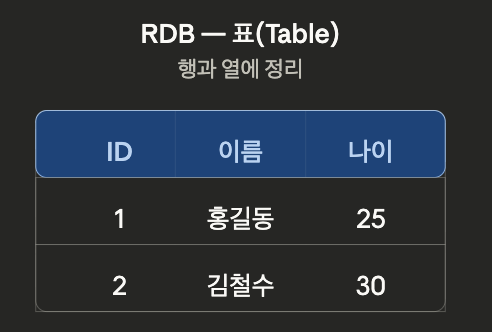

[벡터 DB] - 좌표 공간에 점으로 배치 (의미가 비슷하면 가까이)

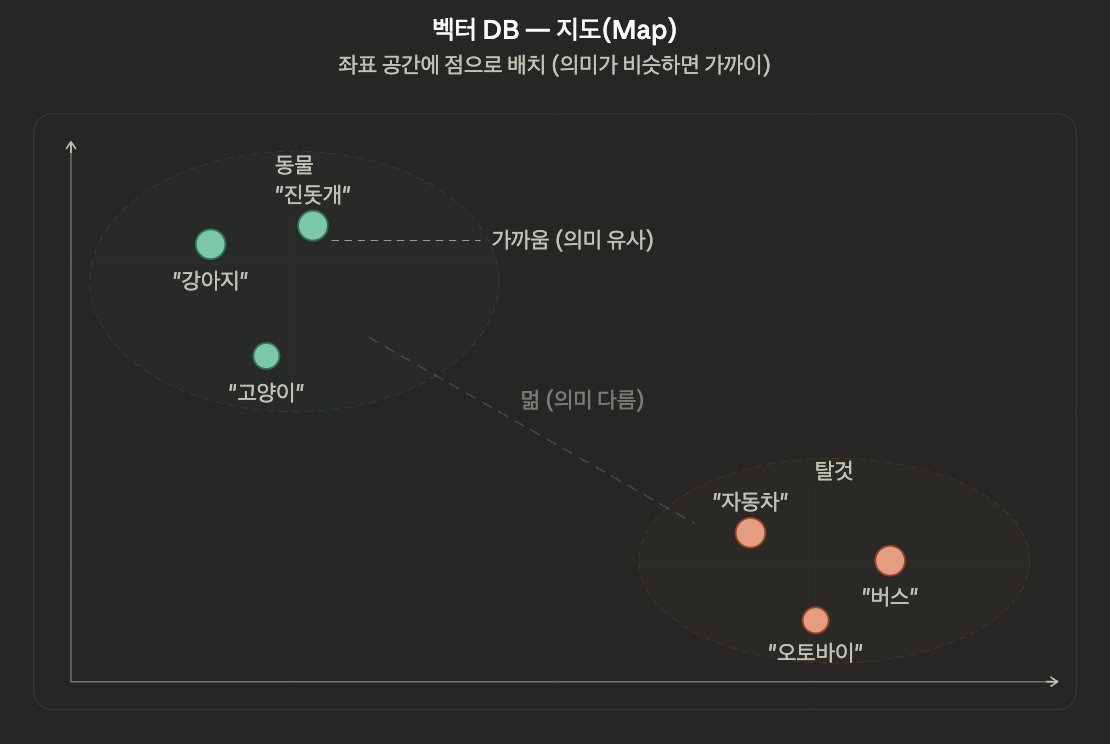

물리적으로는 벡터 DB도 결국 서버의 디스크에 데이터가 쌓인다. 하지만 논리적으로는 각 데이터가 **다차원 좌표 공간에서 위치를 점유**하는 구조이다. 이 좌표에서의 **위치가 곧 의미**이고, **검색은 거리를 재는 것**이다.

### 왜 일반 DB로는 부족한가?

| | 일반 DB | 벡터 DB |
|---|---|---|
| **검색 방식** | 정확한 값 매칭 (=, >, <) | 유사도 기반 근사 검색 |
| **인덱스** | B-Tree, Hash | HNSW, IVF 등 벡터 전용 인덱스 |
| **데이터** | 숫자, 문자열, 날짜 | 고차원 벡터 (수백~수천 차원) |
| **결과** | 조건에 맞는 정확한 결과 | "가장 비슷한" 근사 결과 |

일반 DB에서 벡터 유사도를 계산하려면 모든 행에 대해 코사인 유사도를 계산해야 한다. 이는 O(n)으로, 데이터가 늘어날수록 선형으로 느려진다.

### ANN (Approximate Nearest Neighbor)

벡터 DB의 핵심은 **근사 최근접 이웃(ANN)** 알고리즘이다. 100% 정확한 결과 대신 99%+ 정확도를 허용하는 대신, 검색 속도를 **수십~수백 배** 빠르게 만든다.

```
Exact Search (전수 조사):  벡터 10만 개 × 1536차원 → 모두 비교 → 느림
ANN (근사 검색):           인덱스로 후보를 빠르게 좁힘 → 빠름
```

대표적인 ANN 인덱싱 방식:

| 알고리즘 | 원리 | 특징 |
|---------|------|------|
| **HNSW** | 그래프 기반. 벡터들을 노드로, 가까운 벡터끼리 간선으로 연결한 다층 그래프 | 검색 정확도와 속도 모두 우수하지만 메모리 사용량이 큼. Chroma 기본 방식 |
| **IVF** | 벡터 공간을 여러 클러스터로 나누고, 질문 벡터가 속한 클러스터 주변만 검색 | 메모리 효율적이라 대규모 데이터에 유리하지만 정확도가 약간 낮을 수 있음. FAISS에서 주로 사용 |

> 실무에서 ANN의 내부 동작을 직접 구현할 일은 없다. 중요한 건 "벡터 DB가 어떻게 빠른 검색을 가능하게 하는지"의 원리를 이해하는 것이다.

### 벡터 DB의 동작 흐름

```
[저장]
문서 → 청킹 → 임베딩 모델 → 벡터 + 메타데이터 → 벡터 DB에 저장 (인덱스 구축)

[검색]
질문 → 임베딩 모델 → 질문 벡터 → 벡터 DB에서 ANN 검색 → 상위 k개 문서 반환
```

저장할 때 벡터뿐 아니라 **원본 텍스트**와 **메타데이터**(출처, 페이지 번호 등)도 함께 저장한다. 검색 결과로 벡터가 아닌 원본 텍스트를 돌려받아야 LLM에 전달할 수 있기 때문이다.

### 메타데이터 (Metadata)

벡터 DB에 저장되는 데이터는 크게 세 가지로 구성된다.

| 구성 요소 | 설명 | 예시 |
|----------|------|------|
| **벡터** | 임베딩 모델이 생성한 좌표값. 유사도 검색에 사용 | `[0.12, -0.34, 0.56, ...]` |
| **원본 텍스트** | 벡터의 원래 문서 내용. LLM에 전달할 때 사용 | `"연차는 최소 1일 전에 신청..."` |
| **메타데이터** | 벡터에 붙이는 이름표. 필터링에 사용 | `{"source": "사내규정.pdf", "page": 3}` |

**메타데이터는 임베딩되지 않는다.** 좌표 공간에 점을 찍은 뒤, 그 점에 포스트잇을 붙여놓는 것과 같다. 유사도 검색의 대상이 아니라, 검색 결과를 **필터링**할 때 사용한다.

```
검색 과정:
1. 메타데이터 필터링: "user_id가 'kim'인 데이터만 골라냄"  ← 정확한 매칭 (RDB처럼)
2. 벡터 검색: "골라낸 것 중에서 질문과 가장 가까운 k개 반환"  ← 유사도 기반
```

메타데이터를 쓰는 이유는 벡터 검색만으로는 **"이 데이터가 누구 것인지"**, **"어떤 문서에서 왔는지"** 를 구분할 수 없기 때문이다. 대표적인 사용 사례:

- **멀티테넌트**: 사용자별로 업로드한 문서가 다를 때, `user_id`로 필터링하여 본인 문서만 검색
- **문서 구분**: 여러 PDF를 하나의 컬렉션에 저장하고, `source`로 특정 문서만 검색
- **페이지 범위**: 특정 페이지 범위의 내용만 검색

> LangChain의 Document Loader들은 메타데이터를 **자동으로 생성**한다. 예를 들어 `PyPDFLoader`는 `source`(파일 경로)와 `page`(페이지 번호)를 자동으로 넣어준다. 따로 지정하지 않아도 이 정보로 바로 필터링할 수 있다. 추가 메타데이터가 필요하면 Document 객체의 `metadata` 딕셔너리에 직접 추가하면 된다.

> 메타데이터에 넣을 정보는 **필터링이 필요한 속성**만 포함하면 된다. 만약 메타데이터의 내용으로도 "의미 검색"을 하고 싶다면, 해당 내용을 원본 텍스트에 포함시켜 함께 임베딩해야 한다.

### 벡터 DB 비교

| 벡터 스토어 | 특징 |
|------------|------|
| **Chroma** | 가볍고 간단. 설치가 쉽고 로컬 파일로 저장. 서버 없이 바로 사용 가능 |
| pgvector | PostgreSQL 확장. 기존 DB에 벡터 검색을 추가할 때 유용 |
| FAISS | Meta의 라이브러리. 대규모 벡터에 빠름. 서버 없이 로컬에서 동작 |
| Pinecone | 클라우드 매니지드 서비스. 운영 부담 없음 |

우리는 **Chroma**를 사용한다. 별도 서버 설치 없이 `pip install langchain-chroma`만 하면 바로 사용할 수 있다. 데이터는 로컬 폴더에 파일로 저장되며, 프로그램을 다시 실행해도 유지된다.

## Chroma 실습

In [ ]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import chromadb

COLLECTION_NAME = "spri_ai_brief"  # 컬렉션 이름 (RDB의 테이블에 해당)
PERSIST_DIR = "./chroma_db"  # 저장 폴더 경로 (RDB의 데이터베이스에 해당)

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# 문서 로드 → 분할
loader = PyPDFLoader("data/SPRi AI Brief_9월호_산업동향_0909_F.pdf")
docs = loader.load()

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

print(f"총 {len(chunks)}개 청크를 벡터 DB에 저장합니다...")

# 기존 컬렉션이 있으면 삭제 (중복 방지)
client = chromadb.PersistentClient(path=PERSIST_DIR)
if COLLECTION_NAME in [c.name for c in client.list_collections()]:
    client.delete_collection(COLLECTION_NAME)

# 벡터 스토어 생성 + 문서 저장
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    persist_directory=PERSIST_DIR,
    
)

print("저장 완료!")

총 108개 청크를 벡터 DB에 저장합니다...
저장 완료!


### 유사도 검색

벡터 스토어에 저장된 문서 중 질문과 가장 유사한 것을 찾는다.

In [3]:
# 유사도 검색
query = "즈푸 AI의 AI 모델 이름이 뭐야?"
results = vectorstore.similarity_search(query, k=3)

print(f"질문: {query}\n")
for i, doc in enumerate(results):
    print(f"--- 결과 {i+1} (페이지 {doc.metadata.get('page')}) ---")
    print(doc.page_content[:150])
    print()

질문: 즈푸 AI의 AI 모델 이름이 뭐야?

--- 결과 1 (페이지 9) ---
£즈푸 AI의 GLM-4.5, 추론과 코딩, 에이전트 기능을 통합적으로 지원n중국 AI 기업 즈푸 AI(Zhipu AI)가 추론 기능을 갖춘 플래그십 AI 모델 ‘GLM-4.5’와 ‘GLM-4.5-Air’를 허깅페이스(Hugging Face)와 모델 스코프(ModelS

--- 결과 2 (페이지 9) ---
SPRi AI Brief2025년 9월호
8
즈푸 AI, 추론과 에이전트 성능 강화한 ‘GLM-4.5’ 공개n즈푸 AI가 하나의 모델로 추론과 코딩, 에이전트 기능을 모두 수행할 수 있도록 설계된 전문가 혼합(MOE) 구조의 플래그십 AI 모델 ‘GLM-4.5’와 ‘G

--- 결과 3 (페이지 14) ---
MCP 서버도 출시* AI 모델이 필요 정보를 외부 데이터 소스나 도구와 표준화 방식으로 주고받도록 하는 개방형 통신 규약£구글, 제미나이 2.5 프로의 고급 추론 기능을 활용한 AI 코딩 에이전트 ‘줄스’ 정식 출시n한편, 구글은 2024년 12월 처음 공개한 AI 



### 메타데이터 필터링

`similarity_search`에 `filter` 파라미터를 전달하면, 해당 조건에 맞는 문서만 대상으로 유사도 검색을 수행한다.

In [6]:
# 특정 페이지의 문서만 대상으로 검색
query = "AI 관련 정책은?"
results = vectorstore.similarity_search(query, k=3, filter={"page": 6})

print(f"질문: {query}")
print(f"필터: page == 2\n")
for i, doc in enumerate(results):
    print(f"[{i+1}] (페이지 {doc.metadata.get('page')}) {doc.page_content[:100]}...")
    print()

# 필터 없이 검색하면 다양한 페이지에서 결과가 나옴
results_no_filter = vectorstore.similarity_search(query, k=3)
print("필터 없이 검색한 결과 페이지:", [doc.metadata.get("page") for doc in results_no_filter])

질문: AI 관련 정책은?
필터: page == 2

[1] (페이지 6) 정책･법제기업･산업기술･연구인력･교육
5
미국 연방조달청, AI 플랫폼 ‘USAi’ 공개 및 주요 AI 기업과 제품 제공 계약 체결 n미국 연방조달청이 연방 정부 기관들이 다양한 ...

[2] (페이지 6) 지원∙정부 기관들이 자원의 중복 사용 없이 신기술을 평가할 수 있는 공유 서비스 플랫폼을 제공함으로써 연방 정부의 AI 인프라를 확장하며, 안전한 클라우드 환경에서 확장성과 상호운...

[3] (페이지 6) £GSA, 연방 기관의 생성형 AI 도구 실험과 도입 지원을 위한 ‘USAi’ 플랫폼 공개n미국 연방조달청(GSA)이 2025년 8월 14일 연방 정부 기관들이 안전한 환경에서 다...

필터 없이 검색한 결과 페이지: [2, 6, 27]


In [11]:
# 유사도 점수와 함께 검색
query = "오픈AI의 최신 모델은?"
results = vectorstore.similarity_search_with_score(query, k=3)

print(f"질문: {query}\n")
for doc, score in results:
    print(f"[거리: {score:.4f}] (페이지 {doc.metadata.get('page')}) {doc.page_content[:80]}...")
    print()

질문: 오픈AI의 최신 모델은?

[거리: 0.7258] (페이지 12) 정확도가 향상되어 환각(Hallucination) 비율이 대폭 줄어들었고*, 응답 품질이 개선되어 실생활에 더욱 유용한 답변을 제공하며 창작과 ...

[거리: 0.7636] (페이지 12) 정책･법제기업･산업기술･연구인력･교육
11
오픈AI, 차세대 AI 모델 ‘GPT-5’ 와 개방형 가중치 모델 ‘gpt-oss’ 출시n오픈AI가 ...

[거리: 0.8426] (페이지 12) 예산 절감을 위한 추론 수준 조절도 지원∙오픈AI의 개방형 가중치 모델 출시는 최근 시장에서 폐쇄형 AI 모델을 능가하는 인기를 누리고 있는 딥...



> Chroma의 기본 설정에서 `similarity_search_with_score`는 **유클리드 거리(L2 distance)** 를 반환한다. 값이 **작을수록 유사**하다. (Chroma 설정에 따라 코사인 거리 등 다른 메트릭을 반환할 수도 있다.)
>
> | L2 거리 | 의미 |
> |:---:|:---:|
> | 0.0 | 완전히 동일 |
> | 작은 값 | 유사 |
> | 큰 값 | 무관 |

### 기존 벡터 스토어 연결

이미 저장된 벡터 스토어에 다시 연결할 때는 `from_documents` 대신 생성자를 직접 사용한다. `persist_directory`를 지정하면 이전에 저장한 데이터를 그대로 불러올 수 있다.

> Chroma는 `persist_directory`를 지정하면 데이터가 자동으로 디스크에 저장된다. 예전 버전에서는 `.persist()`를 명시적으로 호출해야 했지만, 현재는 불필요하다. 인터넷 예제에서 `.persist()` 호출이 보이더라도 무시해도 된다.

In [ ]:
# 기존 벡터 스토어에 연결 (임베딩 다시 안 함)
existing_store = Chroma(
    embedding_function=embeddings,
    collection_name=COLLECTION_NAME,
    persist_directory=PERSIST_DIR,
)

# 바로 검색 가능
results = existing_store.similarity_search("구글의 AI 관련 소식은?", k=3)
for doc in results:
    print(doc.page_content[:150])
    print()

> **주의: 임베딩 모델을 바꾸면 벡터 DB를 재구축해야 한다.** 예를 들어 `text-embedding-3-small`로 저장한 벡터 DB에 `text-embedding-3-large`로 검색하면, 벡터 차원도 다르고 좌표 공간 자체가 달라서 검색 결과가 엉망이 된다. 모델을 변경하면 모든 문서를 새 모델로 다시 임베딩하여 저장해야 한다. 실무에서 "검색 품질이 갑자기 나빠졌다"의 원인 중 하나가 임베딩 모델 불일치이므로, 어떤 모델로 저장했는지 반드시 기록해두자.

### Retriever

벡터 스토어의 `similarity_search()`로 직접 검색할 수 있지만, 나중에 LangChain의 체인(Chain)에 연결하려면 **Retriever** 인터페이스가 필요하다. 체인은 `Retriever.invoke(질문) → 문서 리스트` 형태의 통일된 인터페이스를 기대하기 때문이다.

`as_retriever()`로 벡터 스토어를 Retriever로 변환할 수 있으며, `search_kwargs`로 검색 옵션을 지정한다.

In [12]:
# Retriever로 변환하여 사용
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

docs = retriever.invoke("AI 투자 규모는 어느 정도야?")

for doc in docs:
    print(doc.page_content[:150])
    print()

£2025년 가장 빠르게 발전하는 AI 기술로 ‘AI 에이전트’와 ‘AI에 준비된 데이터’ 선정n시장조사기관 가트너(Gartner)가 2025년 8월 5일 ‘2025년 AI 하이프 사이클(Hype Cycle)*’을 발표하고 올해 가장 빠르게 발전하는 AI 기술로 ‘AI

SPRi AI Brief2025년 9월호
14
가트너, 2025년 AI 하이프 사이클 발표n가트너의 2025년 AI 하이프 사이클에 따르면 2025년 들어 운영 확장성과 실시간 인텔리전스 확보를 위한 AI 활용이 주목받으면서 AI 에이전트와 AI에 준비된 데이터가 급부



---

## 실습: PDF 문서 벡터 검색 파이프라인

SPRi AI Brief 9월호 PDF를 벡터 DB에 저장하고, 질문으로 검색하는 파이프라인을 직접 만들어보자.

위에서 실습한 코드를 참고하되, collection_name은 `spri_exercise`로 변경하고, 각 질문당 상위 4개 결과를 출력할 것.

> 아래 질문들은 9월호 **기술·연구** 섹션의 지니 3, 시그라프 2025, 몰모액트 기사를 타겟으로 한다. 검색 결과에 해당 내용이 나오는지 확인해보자.

In [ ]:
pdf_path = "data/SPRi AI Brief_9월호_산업동향_0909_F.pdf"

questions = [
    "월드 모델로 가상 환경을 생성하는 기술은?",
    "컴퓨터 그래픽 분야의 AI 연구 성과는?",
    "3차원 공간에서 행동을 추론하는 AI 모델은?",
]